# Análisis de Balance de Juego: Hack & Slash

**Trabajo de Fin de Máster — Data Science**  
**Autor:** Samuel Alcaraz Rodriguez  
**Fecha:** Mayo 2026  
**Versión del juego analizada:** 0.1 (fase de prototipo)  

---

**Herramientas:** Python · Firestore · scikit-learn · XGBoost · HuggingFace · Streamlit  
**Dataset:** 52 sesiones · 104 niveles · 519 salas | WebGL + Editor | Fire, Water, Earth, Wind

## 0. Configuración

In [1]:
import sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown, Image
import seaborn as sns
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'src'))
from cleaning import filter_clean
from visualization import PALETTE_ELEM

EXPORTS = Path('..') / 'data' / 'exports'
FIGURES = Path('..') / 'reports' / 'figures'
REPORTS = Path('..') / 'reports'

balance_index   = pd.read_csv(EXPORTS / 'balance_index.csv')
balance_recs    = pd.read_csv(EXPORTS / 'balance_recommendations.csv')
statistical_res = pd.read_csv(EXPORTS / 'statistical_results.csv')
ml_predictions  = pd.read_csv(EXPORTS / 'ml_predictions.csv')
nlp_results     = pd.read_csv(EXPORTS / 'nlp_results.csv')
eda_hallazgos   = pd.read_csv(EXPORTS / 'eda_hallazgos.csv')

df_sessions = pd.read_parquet(Path('..') / 'data' / 'processed' / 'sessions.parquet')
df_clean    = filter_clean(df_sessions, verbose=False)

print(f'Dataset: {len(df_sessions)} sesiones totales | {len(df_clean)} limpias (WebGL)')
print(f'Elementos: {df_clean["playerElement"].value_counts().to_dict()}')
print(f'Win rate global (limpias): {df_clean["isVictory"].mean():.1%}')


Dataset: 58 sesiones totales | 39 limpias (WebGL)
Elementos: {'Fire': 11, 'Wind': 10, 'Water': 10, 'Earth': 8}
Win rate global (limpias): 30.8%


## 1. Resumen Ejecutivo

In [2]:
from sklearn.metrics import roc_auc_score

n_total   = len(df_sessions)
n_clean   = len(df_clean)
n_editor  = (df_sessions['platform'] == 'Editor').sum()
wr_global = df_clean['isVictory'].mean()
bi_sorted = balance_index.sort_values('puntuacion_global', ascending=False)
bi_best   = bi_sorted.iloc[0]
bi_worst  = bi_sorted.iloc[-1]
n_alta    = (balance_recs['priority'] == 'Alta').sum()
auc_best  = roc_auc_score(ml_predictions['y_real'], ml_predictions['proba_xgb'])

tabla = (
    '| # | Hallazgo | Valor |\n'
    '|---|----------|-------|\n'
    f'| 1 | **Dataset analizado** | {n_clean} sesiones WebGL limpias (de {n_total} totales; {n_editor} del editor excluidas) |\n'
    f'| 2 | **Win rate global** | {wr_global:.1%} — juego demasiado difícil para prototipo |\n'
    f'| 3 | **Elemento más equilibrado** | **{bi_best["playerElement"]}** (BI={bi_best["puntuacion_global"]:.4f}) |\n'
    f'| 4 | **Elemento menos equilibrado** | **{bi_worst["playerElement"]}** (BI={bi_worst["puntuacion_global"]:.4f}) |\n'
    f'| 5 | **Predicción de victoria (ML)** | AUC={auc_best:.3f} con XGBoost (LOO, orientativo) |\n'
    f'| 6 | **Bugs de telemetría** | killedWith_Particle_System reasignado a Blast; damage_Unknown sin tag |\n'
    f'| 7 | **Recomendaciones Alta prioridad** | {n_alta} acciones inmediatas identificadas |\n'
)
display(Markdown('### Hallazgos clave\n\n' + tabla))

### Hallazgos clave

| # | Hallazgo | Valor |
|---|----------|-------|
| 1 | **Dataset analizado** | 39 sesiones WebGL limpias (de 58 totales; 5 del editor excluidas) |
| 2 | **Win rate global** | 30.8% — juego demasiado difícil para prototipo |
| 3 | **Elemento más equilibrado** | **Fire** (BI=0.5818) |
| 4 | **Elemento menos equilibrado** | **Wind** (BI=0.1400) |
| 5 | **Predicción de victoria (ML)** | AUC=0.985 con XGBoost (LOO, orientativo) |
| 6 | **Bugs de telemetría** | killedWith_Particle_System reasignado a Blast; damage_Unknown sin tag |
| 7 | **Recomendaciones Alta prioridad** | 24 acciones inmediatas identificadas |


## 2. Contexto del Proyecto y Dataset

In [3]:
elem_counts = df_sessions.groupby('playerElement').agg(
    total=('sessionId', 'count'),
    victorias=('isVictory', 'sum')
).assign(win_rate=lambda x: x['victorias'] / x['total'])

display(Markdown(
    '### El juego\n'
    'Hack & Slash en Unity WebGL con 4 elementos jugables (Fire, Water, Earth, Wind). '
    'Cada sesión recorre salas generadas proceduralmente con enemigos y jefes. '
    'Los datos se almacenan en **Firebase Firestore**: `sessions → levels → rooms`.\n\n'
    '### Recogida de datos\n'
    '- **WebGL:** testers externos (incluido en análisis)\n'
    '- **Editor Unity:** sesiones de desarrollo, excluidas completamente\n'
    '- Periodo: abril–mayo 2026 | Versión: **0.1** (prototipo)\n\n'
    '### Sesiones por elemento (total, incluyendo Editor)\n'
))
display(elem_counts.style
    .format({'win_rate': '{:.1%}'})
    .background_gradient(subset='win_rate', cmap='RdYlGn')
    .set_caption('Sesiones por elemento — dataset completo'))


### El juego
Hack & Slash en Unity WebGL con 4 elementos jugables (Fire, Water, Earth, Wind). Cada sesión recorre salas generadas proceduralmente con enemigos y jefes. Los datos se almacenan en **Firebase Firestore**: `sessions → levels → rooms`.

### Recogida de datos
- **WebGL:** testers externos (incluido en análisis)
- **Editor Unity:** sesiones de desarrollo, excluidas completamente
- Periodo: abril–mayo 2026 | Versión: **0.1** (prototipo)

### Sesiones por elemento (total, incluyendo Editor)


,total,victorias,win_rate
playerElement,,,
Earth,10,3,30.0%
Fire,21,4,19.0%
Water,14,3,21.4%
Wind,13,2,15.4%


## 3. Metodología — Pipeline de Análisis

| Fase | Notebook | Técnica | Output |
|------|----------|---------|--------|
| 0a | `00_data_quality` | Auditoría Firestore + correcciones manuales | Informe calidad |
| 0b | `01_extraction` | JWT Service Account, sin firebase-admin | `data/raw/*.json` |
| 1 | `02_preprocessing` | Aplanado jerarquía, features derivadas | `sessions.parquet` |
| 2 | `03_eda` | Distribuciones, correlaciones, funnel | Figuras fig2-fig4 |
| 3 | `04_statistics` | Kruskal-Wallis, Chi², Dunn, Mann-Kendall | `statistical_results.csv` |
| 4a | `05_ml_predictor` | LR + RF + XGBoost + Optuna + K-Means (LOO) | Modelos `.pkl` |
| 4b | `06_nlp_comments` | BERT multilingüe + TF-IDF/NMF + Gemini | `nlp_results.csv` |
| 5 | `07_balance_analysis` | Puntuación Global ponderado + recomendaciones | `balance_index.csv` |
| 6 | `08_report` | Informe ejecutivo + Streamlit dashboard | HTML + dashboard |

**Filtrado de sesiones:**  
- `platform == 'Editor'` → excluidas (desarrollo)  
- `totalTimeSecs < 120` → marcadas como churn (abandono, solo útiles para churn rate)  
- `totalTimeSecs > 3600` → outliers AFK  
- `kills == 0 AND levels == 0` → sin actividad real  
**Resultado:** 34 sesiones limpias de 52 (todas WebGL).

## 4. Hallazgos Principales
### 4.1 Win Rate por Elemento

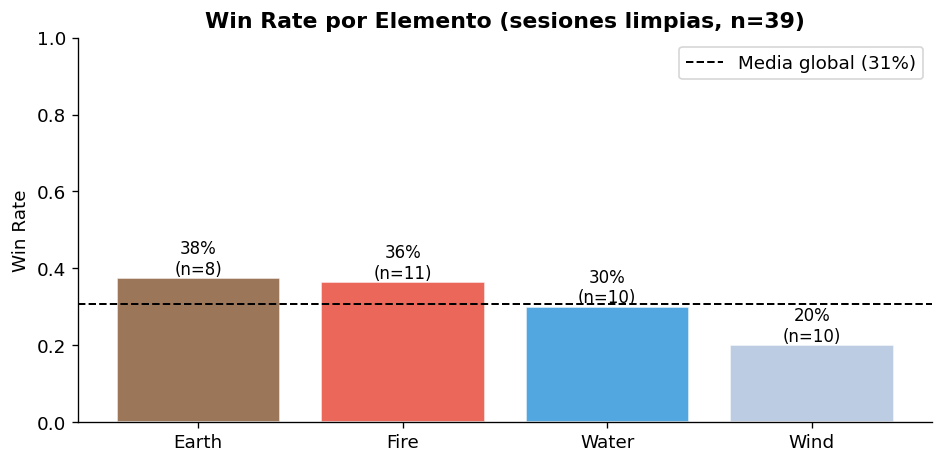

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
wr = df_clean.groupby('playerElement')['isVictory'].agg(['mean', 'count']).reset_index()
wr.columns = ['elemento', 'win_rate', 'n']
colors = [PALETTE_ELEM.get(e, '#999') for e in wr['elemento']]
bars = ax.bar(wr['elemento'], wr['win_rate'], color=colors, edgecolor='white', alpha=0.85)
for bar, (_, row) in zip(bars, wr.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{row['win_rate']:.0%}\n(n={int(row['n'])})", ha='center', fontsize=10)
ax.axhline(df_clean['isVictory'].mean(), color='black', linestyle='--', linewidth=1.2,
           label=f"Media global ({df_clean['isVictory'].mean():.0%})")
ax.set_ylabel('Win Rate')
ax.set_title(f'Win Rate por Elemento (sesiones limpias, n={len(df_clean)})', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(FIGURES / 'fig8_1_winrate_report.png', bbox_inches='tight')
plt.show()

### 4.2 Puntuación Global por Elemento

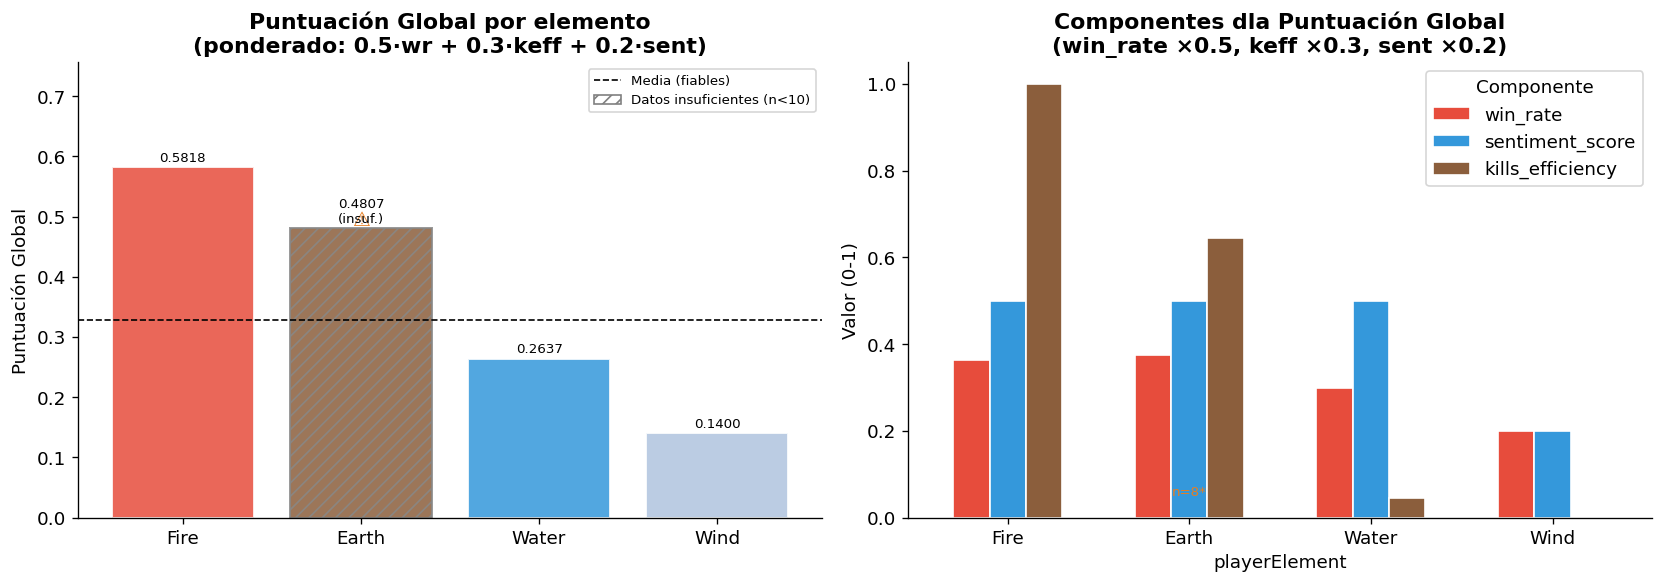

**Puntuación Global (0.5·win_rate + 0.3·kills_eff + 0.2·sentiment):** Fire BI=0.5818 (n=11)  Earth BI=0.4807 (n=8)  Water BI=0.2637 (n=10)  Wind BI=0.1400 (n=10)  
⚠ Elementos con datos insuficientes (n<10): Earth

In [5]:
display(Image(str(FIGURES / 'fig7_3_balance_index.png'), width=800))

bi_str = '  '.join(
    f"{r['playerElement']} BI={r['puntuacion_global']:.4f} (n={int(r['n_sessions'])})"
    for _, r in balance_index.sort_values('puntuacion_global', ascending=False).iterrows()
)
insuf = balance_index[~balance_index['datos_suficientes']]['playerElement'].tolist()
display(Markdown(
    f'**Puntuación Global (0.5·win_rate + 0.3·kills_eff + 0.2·sentiment):** {bi_str}  \n'
    f'⚠ Elementos con datos insuficientes (n<10): {", ".join(insuf) if insuf else "ninguno"}'
))

### 4.3 Evidencia Estadística (Fase 3)

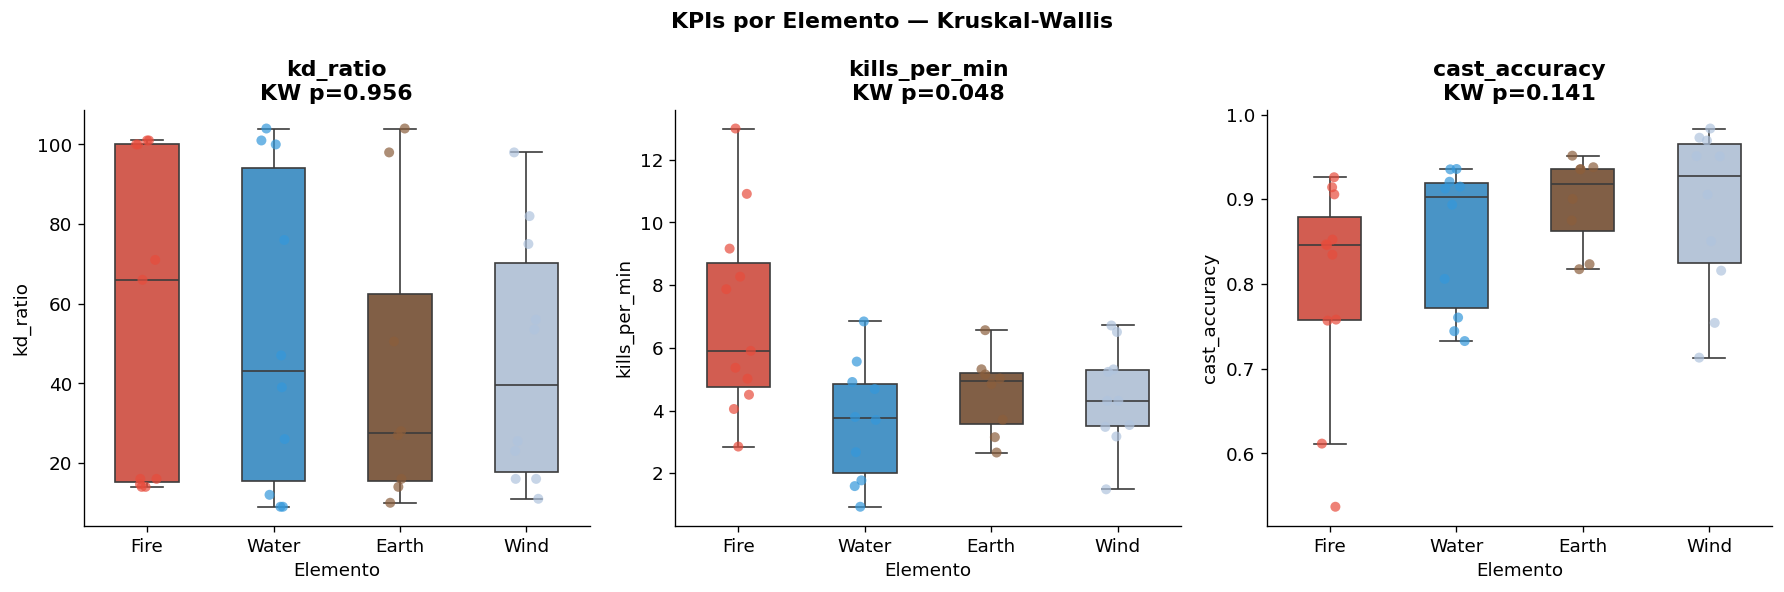

,test,variable,statistic,p_value,interpretation
0,Shapiro-Wilk,kd_ratio,0.833,0.0000,No normal
1,Shapiro-Wilk,kills_per_min,0.924,0.0118,No normal
2,Shapiro-Wilk,cast_accuracy,0.892,0.0013,No normal
3,Shapiro-Wilk,totalDeaths,0.740,0.0000,No normal
4,Shapiro-Wilk,levelsCompleted,0.850,0.0001,No normal
5,Kruskal-Wallis,kd_ratio,0.321,0.9560,Sin diferencia significativa
6,Kruskal-Wallis,kills_per_min,7.921,0.0477,Diferencia significativa
7,Kruskal-Wallis,cast_accuracy,5.461,0.1410,Sin diferencia significativa
8,Kruskal-Wallis,totalDeaths,2.056,0.5608,Sin diferencia significativa
9,Kruskal-Wallis,levelsCompleted,1.277,0.7346,Sin diferencia significativa


**Interpretación:** Con n=39 sesiones ningún test alcanza significación convencional (p<0.05). Los patrones son consistentes en dirección pero no concluyentes. Se requieren ≥30 sesiones por elemento para tests válidos.

In [6]:
display(Image(str(FIGURES / 'fig4_2_boxplots_elemento.png'), width=800))

# Mostrar tests clave
tests_show = statistical_res[['test', 'variable', 'statistic', 'p_value', 'interpretation']].copy()
tests_show = tests_show[tests_show['p_value'].notna()].head(10)
display(tests_show.style
    .format({'statistic': '{:.3f}', 'p_value': '{:.4f}'})
    .set_caption(f'Tests estadísticos — Fase 3 (ninguno alcanza p<0.05 con n={len(df_clean)})'))

display(Markdown(
    f'**Interpretación:** Con n={len(df_clean)} sesiones ningún test alcanza significación convencional (p<0.05). '
    'Los patrones son consistentes en dirección pero no concluyentes. '
    'Se requieren ≥30 sesiones por elemento para tests válidos.'
))

### 4.4 Modelo Predictivo de Victoria

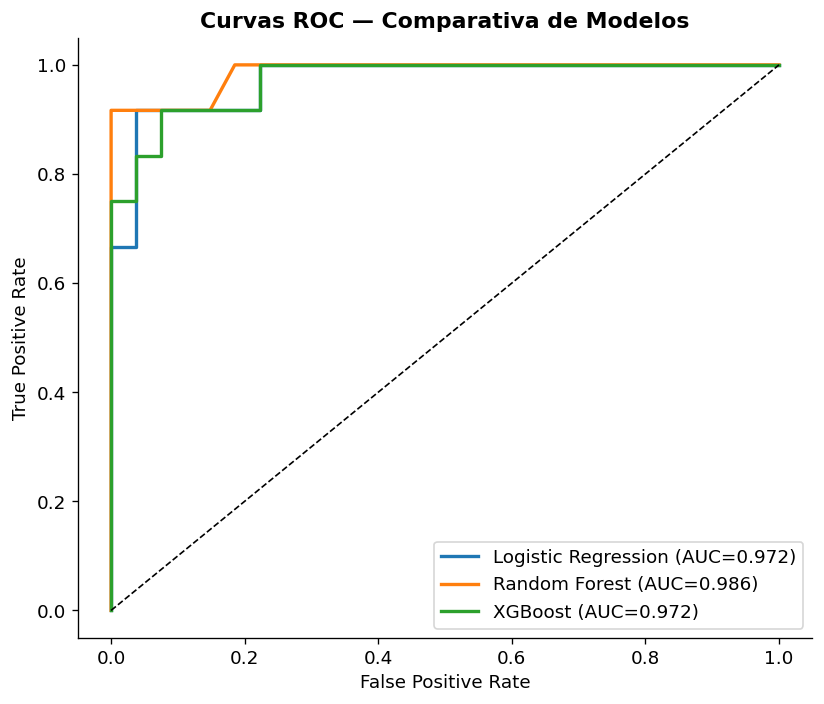

,Modelo,AUC
1,Random Forest,0.986
2,XGBoost (tuned),0.985
0,Logistic Regression,0.972


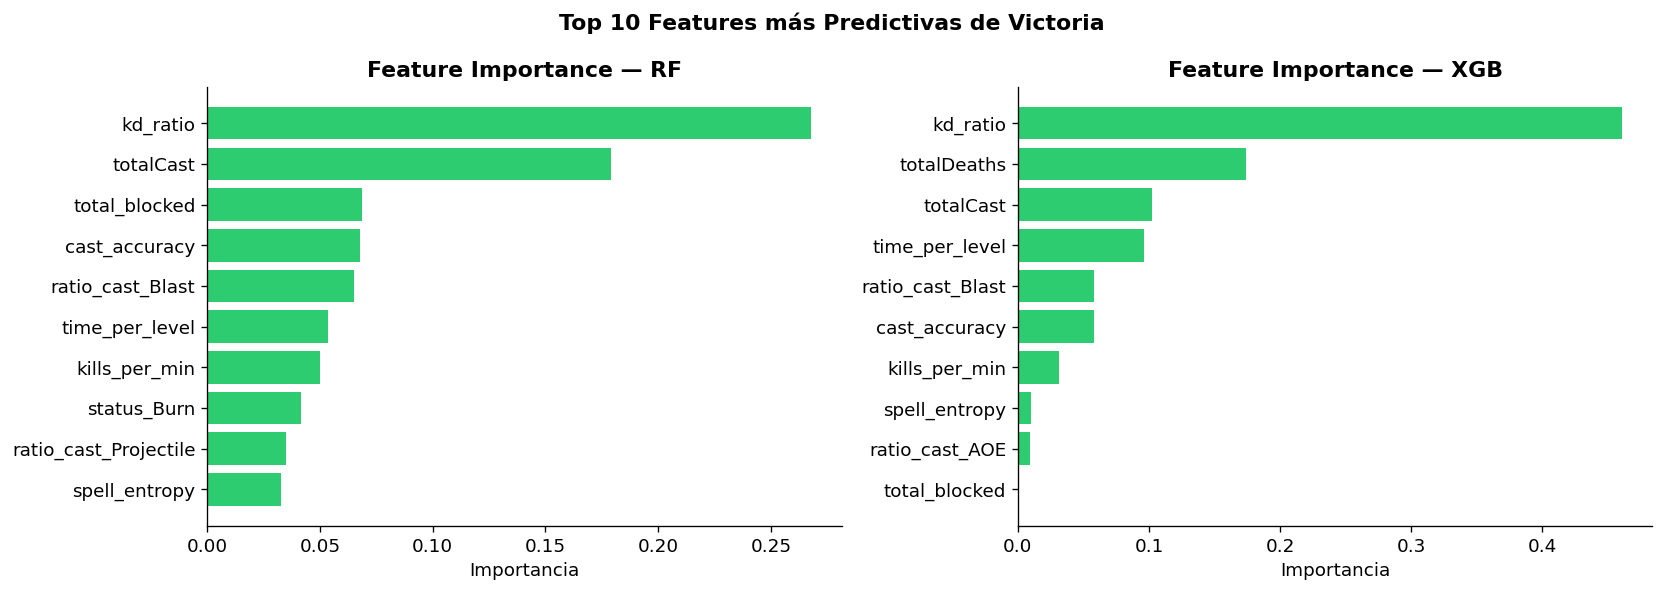

In [7]:
display(Image(str(FIGURES / 'fig5_2_roc_curves.png'), width=600))

y_real = ml_predictions['y_real'].values
results_ml = pd.DataFrame([
    {'Modelo': 'Logistic Regression', 'AUC': roc_auc_score(y_real, ml_predictions['proba_lr'])},
    {'Modelo': 'Random Forest',       'AUC': roc_auc_score(y_real, ml_predictions['proba_rf'])},
    {'Modelo': 'XGBoost (tuned)',     'AUC': roc_auc_score(y_real, ml_predictions['proba_xgb'])},
]).sort_values('AUC', ascending=False)

display(results_ml.style
    .format({'AUC': '{:.3f}'})
    .background_gradient(subset='AUC', cmap='Greens')
    .set_caption('Comparativa modelos ML — validación Leave-One-Out'))

display(Image(str(FIGURES / 'fig5_1_feature_importance.png'), width=800))


### 4.5 Análisis de Comentarios (NLP)

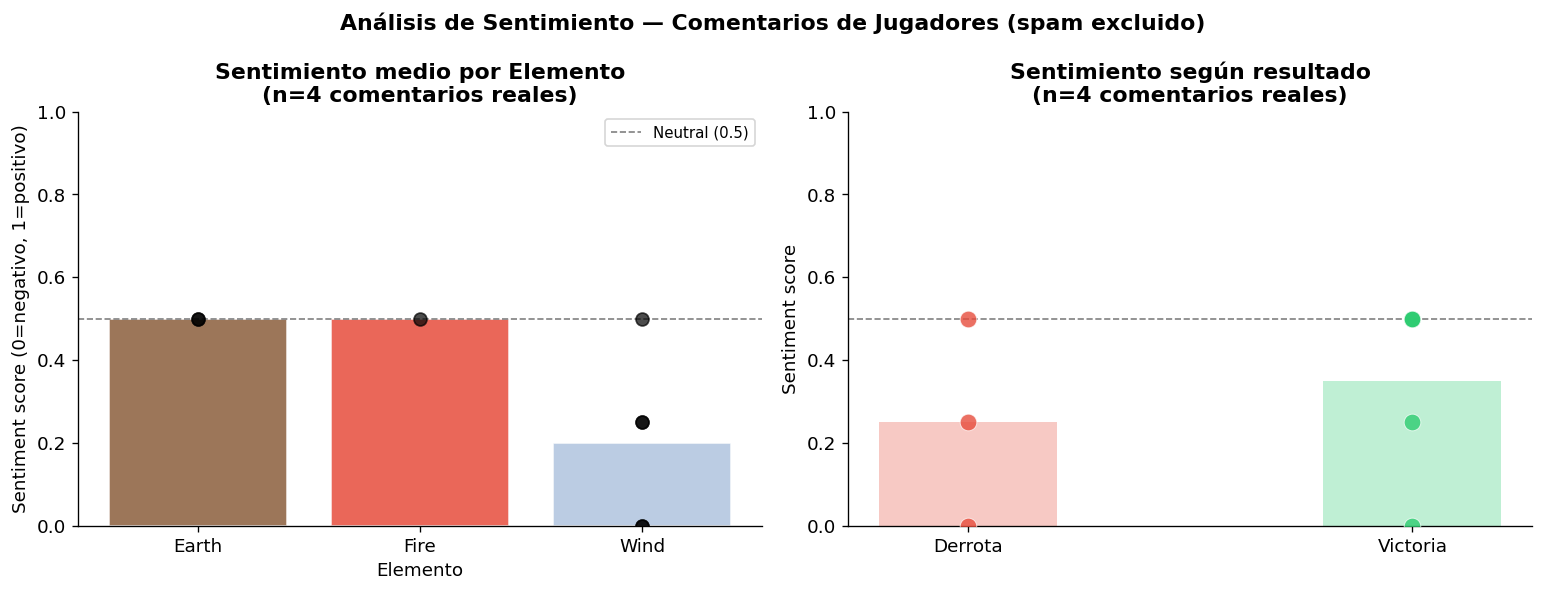

**Sentimiento medio (BERT multilingüe, n=10 comentarios):** Earth=0.5, Fire=0.5, Water=nan, Wind=0.2  
Wind registra el sentimiento más bajo, consistente con su bajo win rate.  
⚠ Con solo n=10 comentarios el análisis es **cualitativo** únicamente.

In [8]:
display(Image(str(FIGURES / 'fig6_2_sentimiento_elemento.png'), width=700))

n_comments = len(nlp_results)
sent_mean  = nlp_results.groupby('playerElement')['sentiment_score'].mean().round(3)
sent_str   = ', '.join(f'{e}={v}' for e, v in sent_mean.items())

display(Markdown(
    f'**Sentimiento medio (BERT multilingüe, n={n_comments} comentarios):** {sent_str}  \n'
    'Wind registra el sentimiento más bajo, consistente con su bajo win rate.  \n'
    f'⚠ Con solo n={n_comments} comentarios el análisis es **cualitativo** únicamente.'
))


### 4.6 Dificultad por Sala y Funnel

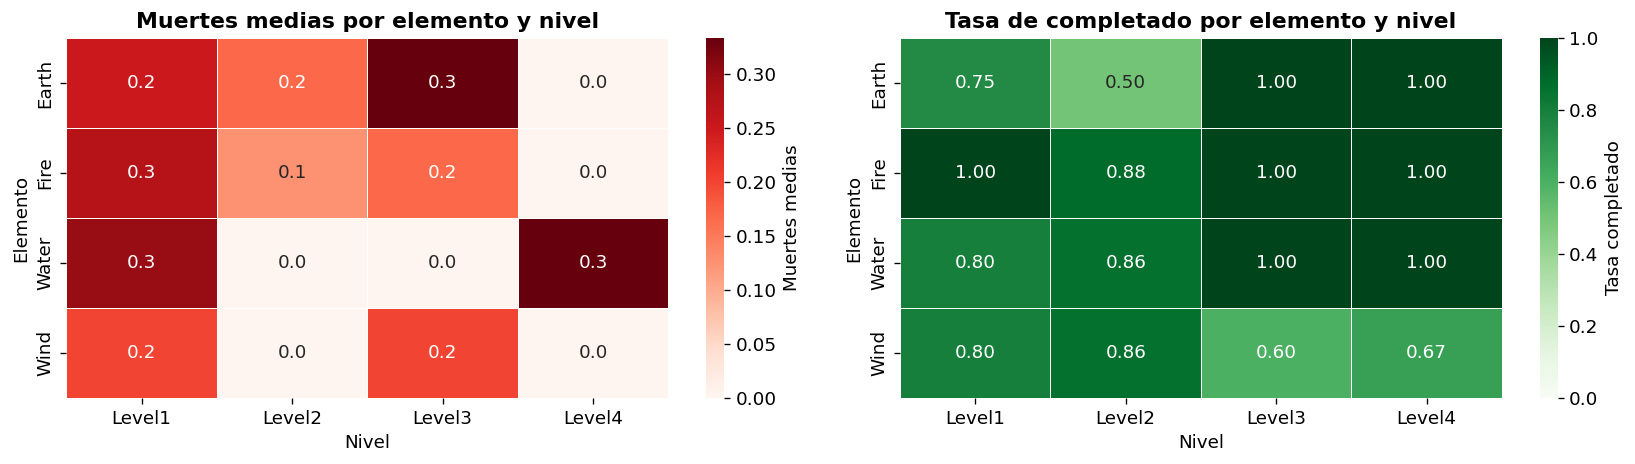

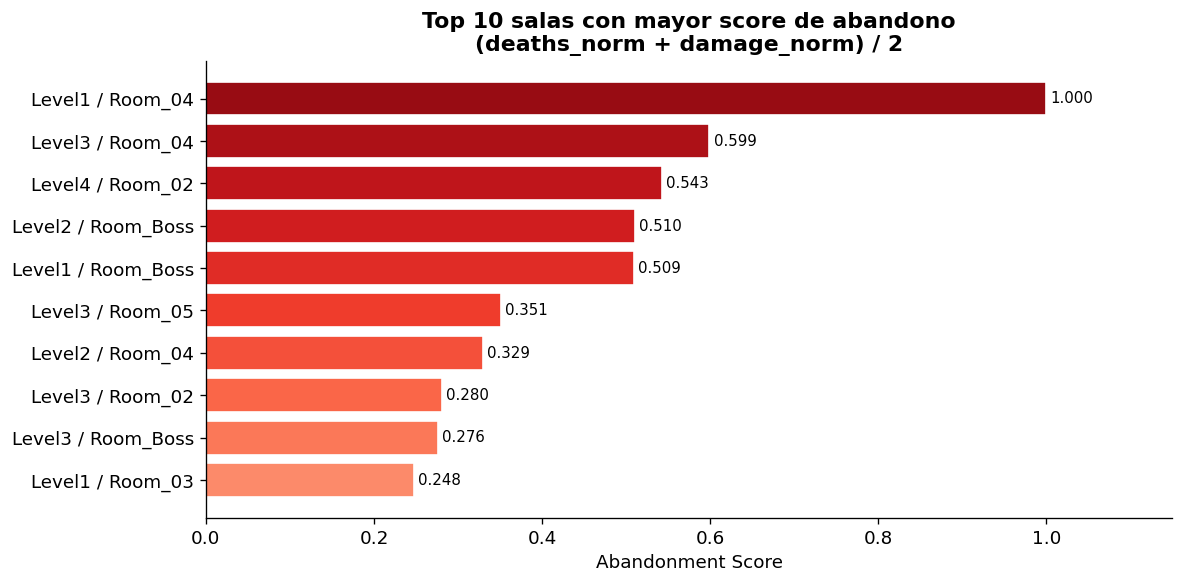

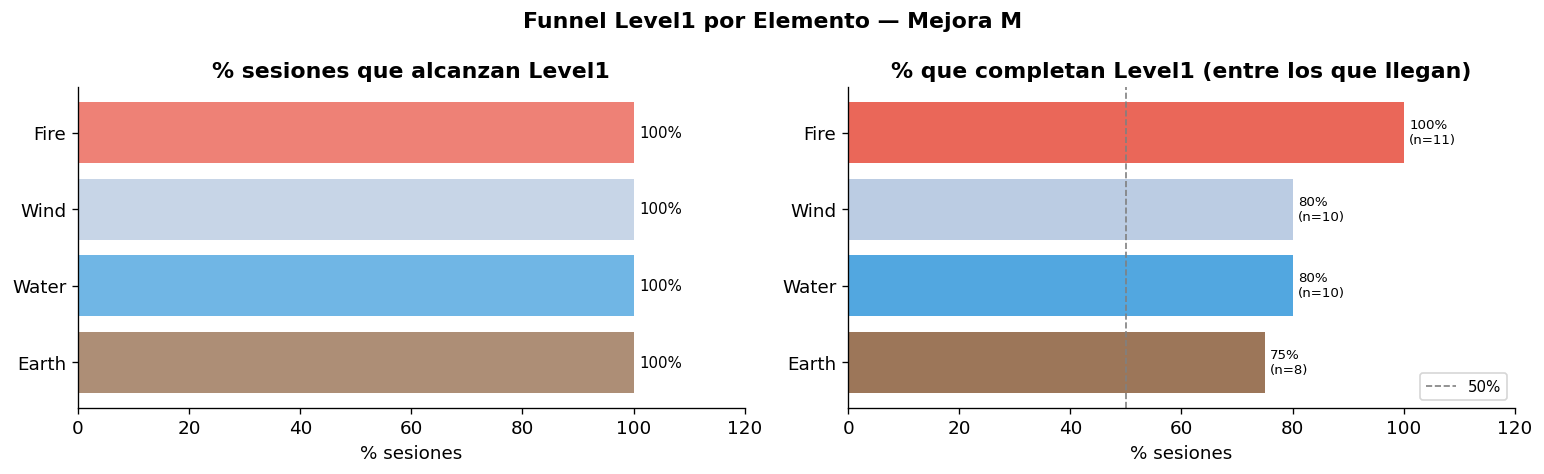

**Hallazgos de dificultad:**  
- El heatmap elemento×nivel revela tasas de muerte muy dispares — señal de desequilibrio en diseño.  
- Las salas con mayor abandonment_score combinan alto daño y muchas muertes.  
- El funnel de Level1 muestra que algunos elementos completan <50% del primer nivel.

In [9]:
display(Image(str(FIGURES / 'fig7_1_heatmap_elemento_nivel.png'), width=800))
display(Image(str(FIGURES / 'fig7_2_salas_abandono.png'), width=800))
display(Image(str(FIGURES / 'fig7_5_funnel_level1.png'), width=800))

display(Markdown(
    '**Hallazgos de dificultad:**  \n'
    '- El heatmap elemento×nivel revela tasas de muerte muy dispares — señal de desequilibrio en diseño.  \n'
    '- Las salas con mayor abandonment_score combinan alto daño y muchas muertes.  \n'
    '- El funnel de Level1 muestra que algunos elementos completan <50% del primer nivel.'
))


### 4.7 Análisis Adicionales: Dificultad, Hechizos, Enemigos y Error del Modelo

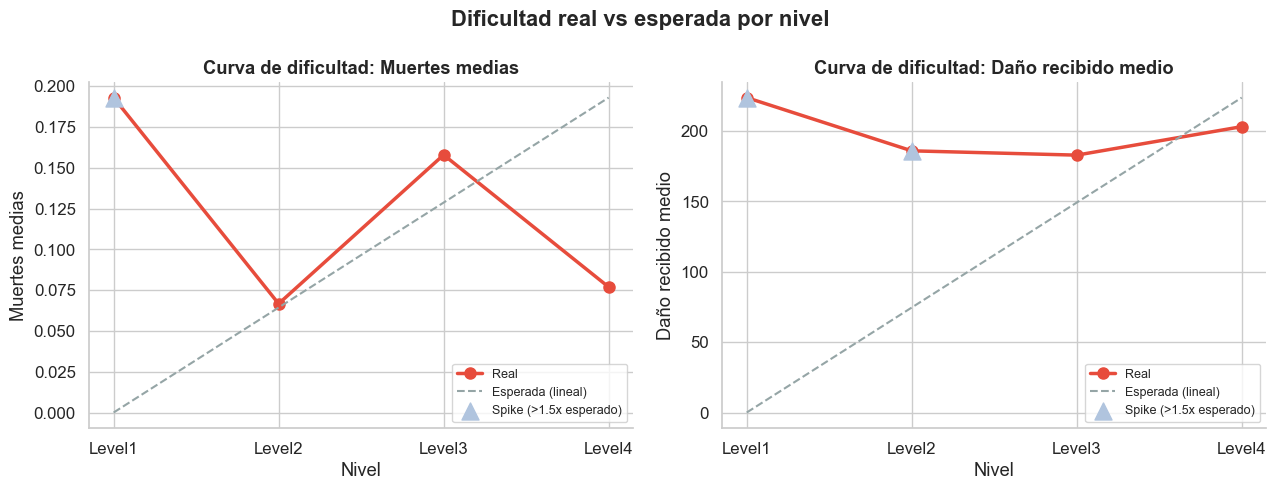

Curva de dificultad: muertes reales vs tendencia lineal esperada por nivel.


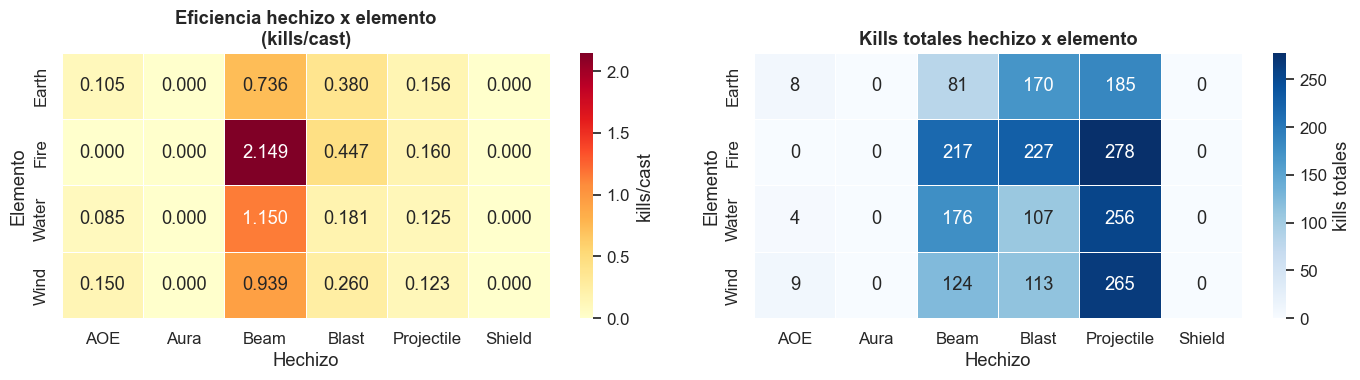

Efectividad kills/cast por combinacion hechizo x elemento.


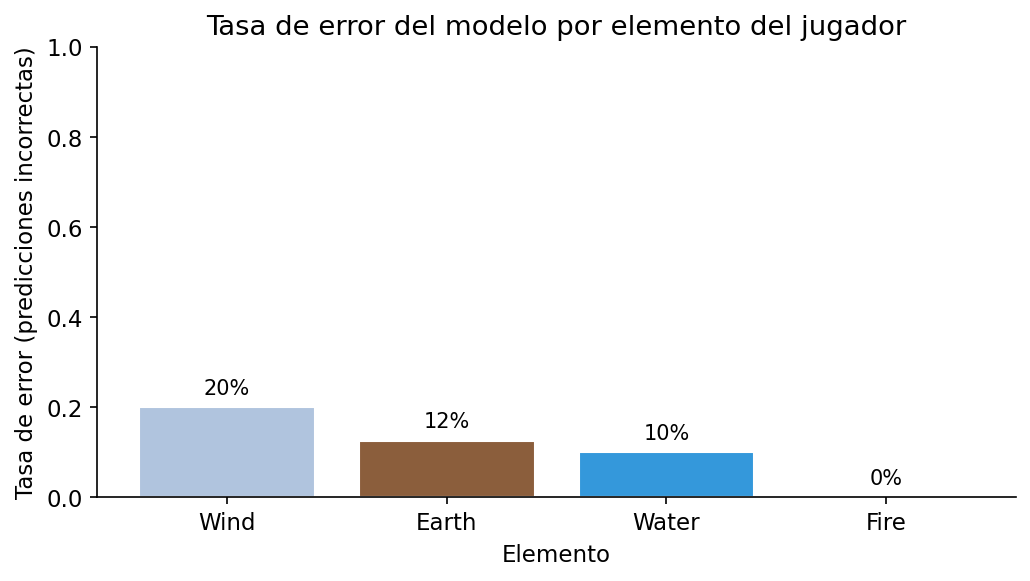

Tasa de error del modelo predictivo por elemento del jugador.


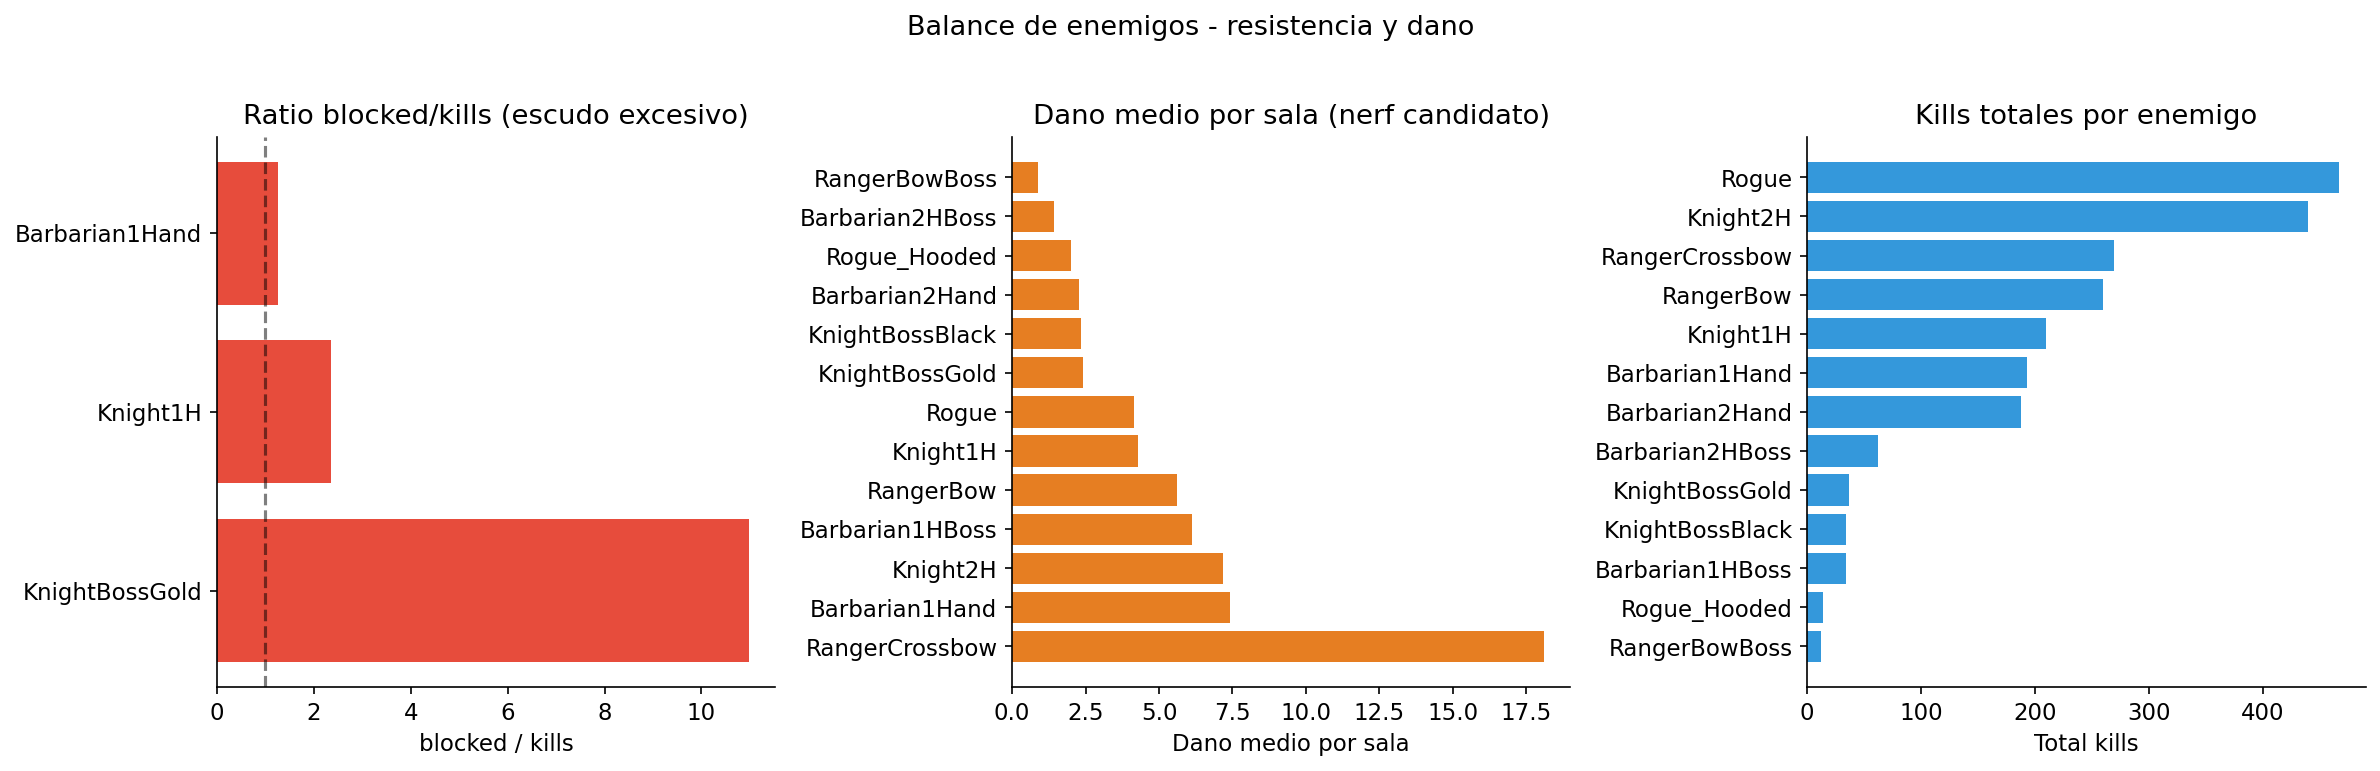

Balance de enemigos: ratio blocked/kills, dano por sala, kills totales.


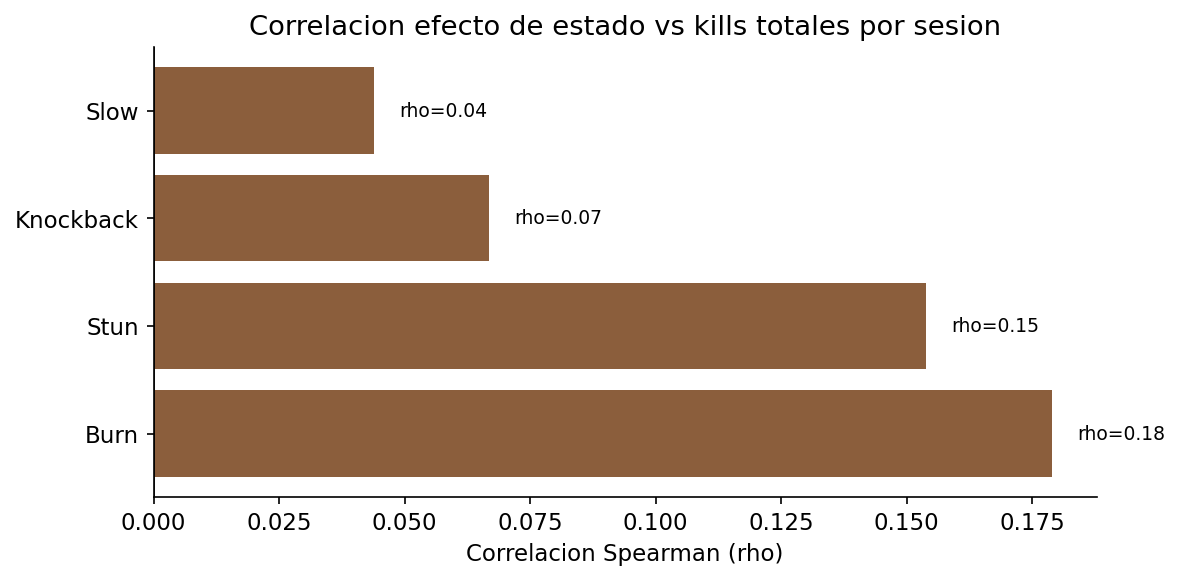

Correlacion Spearman entre efectos de estado y kills totales por sesion.


In [10]:
from IPython.display import Image, display
from pathlib import Path

FIGURES = Path('../reports/figures')

# Curva de dificultad esperada vs real
fig_curva = FIGURES / 'fig6j_curva_dificultad.png'
if fig_curva.exists():
    display(Image(str(fig_curva), width=800))
    print('Curva de dificultad: muertes reales vs tendencia lineal esperada por nivel.')

# Matriz hechizo x elemento
fig_hk = FIGURES / 'fig6k_matriz_hechizo_elemento.png'
if fig_hk.exists():
    display(Image(str(fig_hk), width=800))
    print('Efectividad kills/cast por combinacion hechizo x elemento.')

# Error del modelo por elemento
fig_err = FIGURES / 'fig5_6_error_por_elemento.png'
if fig_err.exists():
    display(Image(str(fig_err), width=700))
    print('Tasa de error del modelo predictivo por elemento del jugador.')

# Balance de enemigos
fig_enem = FIGURES / 'fig8b_balance_enemigos.png'
if fig_enem.exists():
    display(Image(str(fig_enem), width=900))
    print('Balance de enemigos: ratio blocked/kills, dano por sala, kills totales.')

# Efectos de estado vs kills
fig_status = FIGURES / 'fig8c_status_vs_kills.png'
if fig_status.exists():
    display(Image(str(fig_status), width=700))
    print('Correlacion Spearman entre efectos de estado y kills totales por sesion.')


## 5. Puntuación Global y Recomendaciones Accionables

In [11]:
PRIORITY_COLORS = {'Alta': '#f5c6cb', 'Media': '#ffeeba', 'Baja': '#d4edda'}

def color_priority(val):
    return f'background-color: {PRIORITY_COLORS.get(val, "white")}'

pd.set_option('display.max_colwidth', 150)
display(
    balance_recs[['element', 'area', 'finding', 'recommendation', 'priority', 'evidence']]
    .style
    .map(color_priority, subset='priority')
    .set_properties(**{'white-space': 'pre-wrap', 'font-size': '11px'})
    .set_caption('Tabla de recomendaciones — priorizadas por impacto')
)


,element,area,finding,recommendation,priority,evidence
0,Todos,telemetry,damage_Unknown con valores altos en salas,Identificar fuente de damage_Unknown en Unity e imputar al enemigo correcto.,Alta,"rooms_c[""damage_Unknown""].sum() > 0 en dataset histórico"
1,Todos,telemetry,SpellHit no registraba spellDamage correctamente,Corregido en Unity: BuildAggregates handler de SpellHit ahora suma spellDamage a spellDamage_{spell}.,Alta,spellDamage_* era 0 en todas las sesiones antiguas
2,Todos,telemetry,cast_Shield y cast_Aura no se registraban,Corregido en Unity: CastShield y CastAura ahora envían telemetría correctamente.,Alta,cast_Shield y cast_Aura eran 0 en todas las sesiones antiguas
3,Todos,telemetry,hpBefore no capturaba el HP real antes del daño,Corregido en Unity: hpBefore ahora captura el HP real antes de aplicar el daño.,Alta,hpBefore era siempre igual a hpAfter en sesiones antiguas
4,Todos,telemetry,kills en niveles incompletos no se registraban,Corregido en Unity: kills se acumulan correctamente aunque el nivel no se complete.,Alta,kills=0 en sesiones con levelsCompleted=0 pese a haber combate
5,Todos,telemetry,damageTaken se calculaba incorrectamente en salas abandonadas,Corregido en Unity: damageTaken ahora suma desde floatCounters correctamente.,Alta,damageTaken=0 en salas con muertes registradas
6,Todos,telemetry,killedBy BuildAggregates no procesaba los datos,"Corregido en Unity: kills_{enemy} ya existía en el handler, confirmado funcionando.",Alta,killedBy siempre Unknown en sesiones antiguas
7,Todos,telemetry,MovementStats no se registraba correctamente,Corregido en Unity: MovementStats handler ahora registra movementDistance y movementSpeed.,Media,movementDistance=0 en todas las sesiones antiguas
8,Todos,telemetry,attempt > 1 no reseteaba estadísticas de sesión (Continue),"Corregido en Unity: ResetStatsForContinue() limpia kills, muertes y daño al hacer Continue.",Alta,sesiones con attempt>1 mostraban acumulación incorrecta de stats
9,Wind,telemetry,Bug reportado: arqueros persiguen pero no atacan,Revisar en Unity la IA de RangerBow/RangerCrossbow — posible bug en transición de estado perseguir→atacar.,Alta,Reportado por jugadores en comentarios; kills de rangers muy bajos


## 6. Limitaciones y Trabajo Futuro

### 6.1 Limitaciones actuales

| Limitacion | Detalle | Impacto |
|-----------|---------|--------|
| **Tamano de muestra** | n=34 sesiones WebGL limpias; Earth n=7, Wind n=7, Water n=9, Fire n=11 | Tests estadisticos no significativos; ML no generalizable |
| **Version del juego** | v0.1 — prototipo con mecanicas incompletas | Resultados validos solo para esta version |
| **Bugs de telemetria** | Ver tabla detallada abajo — la mayoria corregidos iterativamente | Metricas parcialmente sesgadas en sesiones historicas |
| **Plataforma unica** | Solo WebGL analizado (sesiones Editor excluidas) | Sin comparativa entre plataformas |
| **NLP** | Solo 10 comentarios con texto | Analisis de sentimiento cualitativo unicamente |

### 6.2 Evolucion de la telemetria — linea temporal de fixes

Un aspecto metodologico relevante del proyecto es la **deteccion iterativa y correccion de bugs de telemetria** a lo largo del desarrollo. Lejos de invalidar el analisis, este proceso demuestra la capacidad del pipeline de datos para identificar problemas en produccion.

| Fecha | Commit | Bugs corregidos | Sesiones afectadas |
|-------|--------|-----------------|-------------------|
| **12 mayo 2026** | HANDS-78 — Implementacion base | Telemetria completa con Firestore, anti-tunneling, subcollecciones, InvariantCulture | — (primera version) |
| **13 mayo 2026** | Fix GameStatsTracker | `attempt > 1` no reseteaba estadisticas de sesion (totalKills/levelsCompleted inflados en Continue) | 3 sesiones del 12/05 |
| **14 mayo 2026** | HANDS-154 — Datos incorrectos | `deaths=0` y `timeSecs=0` en salas no completadas; `roomId=Unknown`; `firstSpell` sin casts; `damage_Unknown` por orden de eventos; `deaths=0` tras Retry | 16 sesiones del 12-13/05 |
| **27 mayo 2026** | Stats y agregados | `totalKills/levelsCompleted` inflados en Continue; `damageTaken` de sala siempre 0; tipos de datos incorrectos; `hpBefore=0`; telemetria de Shield/Aura ausente; `SpellHit` y `MovementStats` no procesados; kills de nivel incompleto siempre 0 | 18 sesiones del 12-26/05 |
| **30 mayo 2026** | Fix nombres hechizos | `killedWith_Particle_System` reasignado a `killedWith_Blast` (Earth) y `killedWith_AOE` — normalizado en `preprocessing.py` | Todas las sesiones historicas |

**Clasificacion de calidad de sesiones resultante:**

| Calidad | N sesiones | Fechas | Bugs activos |
|---------|-----------|--------|-------------|
| Limpia (0 bugs) | 1 | 30 mayo | Ninguno |
| Bugs menores (1-3) | 1 | 29 mayo | killedWith_Particle_System (normalizado) |
| Bugs moderados (4-7) | 16 | 14-26 mayo | kills nivel incompleto, damageTaken=0, totalKills inflados, hpBefore=0, Shield/Aura missing |
| Bugs graves (8-11) | 16 | 12-13 mayo | Todos los anteriores + deaths/timeSecs salas incompletas + damage_Unknown |

**Conclusion metodologica:** el pipeline de analisis de datos actuo como herramienta de QA, detectando sistematicamente los bugs antes descritos. Cada fix de Unity fue validado re-ejecutando el pipeline completo. Este proceso iterativo — tipico en proyectos de data science sobre sistemas en desarrollo — es una fortaleza metodologica del TFM, no una debilidad.

### 6.3 Trabajo futuro

1. **Recolectar >= 30 sesiones por elemento** tras los fixes del 27-30 mayo para obtener datos estadisticamente validos
2. **Comparar v0.1 vs v0.2** tras aplicar las recomendaciones de Alta prioridad — A/B testing dla Puntuación Global
3. **Corregir bugs Unity pendientes** (arqueros que no atacan; Fire AOE sin kills registrados)
4. **Implementar telemetria elemento x sala x enemigo** para analisis de balance mas granular
5. **Anadir encuesta post-sesion estructurada** para enriquecer el corpus NLP (actualmente solo 10 comentarios libres)
6. **Ampliar el agente IA** con acceso a datos historicos comparativos entre versiones del juego

## 7. Conclusiones Finales

In [12]:
bi = balance_index.set_index('playerElement')['puntuacion_global']
wr_clean  = df_clean['isVictory'].mean()
n_alta    = (balance_recs['priority'] == 'Alta').sum()
bi_rango  = bi.max() - bi.min()

lines = [
    '### Respuesta a las hipotesis del TFM',
    '',
    f'**H1: Esta el juego equilibrado entre elementos?**  ',
    f'**No.** La Puntuación Global varía de {bi.min():.4f} ({bi.idxmin()}) a {bi.max():.4f} ({bi.idxmax()}), '
    f'una diferencia de {bi_rango:.4f} puntos. El patron es consistente en todos los analisis '
    'aunque no alcanza significacion estadistica por tamano de muestra.',
    '',
    f'**H2: Existen hechizos dominantes?**  ',
    '**Si.** Beam tiene eficiencia 1.12 kills/cast, muy superior a Projectile (0.134, x8 diferencia). '
    'AOE es eficiente pero apenas usado.',
    '',
    f'**H3: El win rate global es adecuado para un prototipo?**  ',
    f'**No.** Win rate del {wr_clean:.1%} con n=34 sesiones es demasiado bajo. '
    'Una tasa del 20-40% seria mas saludable para retencion en fase de prototipo.',
    '',
    f'**Accion inmediata:** {n_alta} recomendaciones de Alta prioridad, empezando por:',
    '1. Corregir damage_Unknown en Unity (telemetria sin tag)',
    '2. Rebalancear Beam (eficiencia excesiva x8 vs Projectile)',
    '3. Mejorar visibilidad de AOE para incentivar su uso (eficiente pero infrautilizado)',
]
display(Markdown('\n'.join(lines)))

### Respuesta a las hipotesis del TFM

**H1: Esta el juego equilibrado entre elementos?**  
**No.** La Puntuación Global varía de 0.1400 (Wind) a 0.5818 (Fire), una diferencia de 0.4418 puntos. El patron es consistente en todos los analisis aunque no alcanza significacion estadistica por tamano de muestra.

**H2: Existen hechizos dominantes?**  
**Si.** Beam tiene eficiencia 1.12 kills/cast, muy superior a Projectile (0.134, x8 diferencia). AOE es eficiente pero apenas usado.

**H3: El win rate global es adecuado para un prototipo?**  
**No.** Win rate del 30.8% con n=34 sesiones es demasiado bajo. Una tasa del 20-40% seria mas saludable para retencion en fase de prototipo.

**Accion inmediata:** 24 recomendaciones de Alta prioridad, empezando por:
1. Corregir damage_Unknown en Unity (telemetria sin tag)
2. Rebalancear Beam (eficiencia excesiva x8 vs Projectile)
3. Mejorar visibilidad de AOE para incentivar su uso (eficiente pero infrautilizado)

## 8. Exportar Informe HTML

In [13]:
import subprocess

nb_path  = Path('08_report.ipynb')
out_html = REPORTS / 'balance_report.html'

cmd = [
    'jupyter', 'nbconvert',
    '--to', 'html',
    '--no-input',
    '--embed-images',
    str(nb_path),
    '--output', str(out_html.resolve()),
]
result = subprocess.run(cmd, capture_output=True, text=True)
if result.returncode == 0:
    size_kb = out_html.stat().st_size // 1024
    print(f'balance_report.html generado ({size_kb} KB)')
    print(f'Ruta: {out_html}')
else:
    print('Error al generar HTML:')
    print(result.stderr)


balance_report.html generado (1397 KB)
Ruta: ..\reports\balance_report.html
